# 📊 Notebook 06 — Model Evaluation

## 🎯 Objective
This notebook performs a **comprehensive evaluation** of the trained heart disease prediction models,
focusing on **test-set performance, calibration, interpretability, and threshold optimization**.

The goal is to validate how well the selected model generalizes to unseen data and to
generate visual and quantitative evidence that supports its predictive reliability.

---

## ⚙️ Workflow Overview
1. **Load best model**  
   Retrieve the highest-performing model identified in `05_model_training.ipynb` (via `reports/best_model.json`).

2. **Load test data**  
   Use the unseen test split prepared in `02_data_loading_preprocessing.ipynb`.

3. **Generate predictions**  
   Compute probabilities and class predictions using the trained pipeline (preprocessing + model).

4. **Evaluate performance**  
   - Compute key metrics (ROC-AUC, Average Precision, Accuracy, F1, Precision, Recall)  
   - Visualize **ROC** and **Precision-Recall** curves  
   - Plot **Confusion Matrix** and **Calibration Curve**

5. **Threshold tuning**  
   Explore different probability thresholds to balance sensitivity and specificity.

6. **Model interpretability (optional)**  
   - Inspect **feature importances** or **coefficients**  
   - Visualize SHAP summary plots for model explainability (if supported)

7. **Save reports**  
   Store all evaluation metrics and plots under the `reports/` directory for reproducibility.

---

## 📦 Expected Outputs
| File | Description |
|------|--------------|
| `reports/test_metrics_<run_id>.json` | Quantitative test metrics (AUC, AP, Precision, Recall, etc.) |
| `reports/roc_curve_<run_id>.png` | ROC curve plot |
| `reports/pr_curve_<run_id>.png` | Precision–Recall curve |
| `reports/confusion_matrix_<run_id>.png` | Confusion matrix visualization |
| `reports/calibration_curve_<run_id>.png` | Model calibration plot |
| `reports/evaluation_summary_<run_id>.json` | Combined summary of all metrics and thresholds |

---

## 🚀 Goal
By the end of this notebook, you will have:
- A **finalized, fully evaluated model** for predicting heart disease risk  
- Quantitative metrics and diagnostic plots demonstrating generalization performance  
- Evidence and interpretability artifacts supporting deployment or clinical review

---

## 📁 Dependencies
Before running this notebook, ensure:
- The best model has been trained and saved in `models/heart_model_<run_id>.pkl`
- Processed test data is available under `data/processed/`
- Supporting scripts exist in:
  - `src/data.py` — for accessing processed data  
  - `src/features.py` — for consistent preprocessing pipeline definitions  

---


In [1]:
# (Colab only) mount & cd
IN_COLAB = "google.colab" in str(get_ipython())
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Dr. Taiwo famuyiwa - Data Science & Biostatistics Portfolio/Machine Learning Projects/Heart-Disease-Prediction



Mounted at /content/drive
/content/drive/MyDrive/Dr. Taiwo famuyiwa - Data Science & Biostatistics Portfolio/Machine Learning Projects/Heart-Disease-Prediction


## 0) Setup & imports

In [2]:
# std libs
import os, sys, json, warnings
warnings.filterwarnings("ignore")
sys.path.append(os.getcwd())

# data/plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, brier_score_loss
)
from sklearn.calibration import CalibrationDisplay

# project paths
from pathlib import Path
from src.data import PROC_DIR

REPORTS_DIR = Path("reports"); REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR  = Path("models")


## 1) Load test split

In [3]:
X_test = pd.read_csv(PROC_DIR / "X_test.csv")
y_test = pd.read_csv(PROC_DIR / "y_test.csv").squeeze("columns")
X_test.shape, y_test.mean().round(3)


((61, 13), np.float64(0.459))

## 2) Locate & load the "best" model

In [4]:
import joblib

# prefer pointer written in Notebook 05
best_meta_path = REPORTS_DIR / "best_model.json"
if best_meta_path.exists():
    best_meta = json.loads(best_meta_path.read_text())
    best_run  = best_meta["best_run_id"]
    model_path = MODELS_DIR / f"heart_model_{best_run}.pkl"
else:
    # fallback: pick the newest model artifact
    candidates = sorted(MODELS_DIR.glob("heart_model_*.pkl"), key=lambda p: p.stat().st_mtime, reverse=True)
    assert candidates, "No model artifacts found in models/."
    model_path = candidates[0]
    best_run = model_path.stem.replace("heart_model_", "(unknown-run)")

print("Loading:", model_path.name)
pipe = joblib.load(model_path)


Loading: heart_model_logreg_seed42_1761362412.pkl


## 3) Predict on test (proba + labels)

In [5]:
proba = pipe.predict_proba(X_test)[:, 1]
default_thr = 0.5
preds = (proba >= default_thr).astype(int)


## 4) Core metrics (AUC/ AP/ Accuracy/Report) + save

In [6]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

metrics = {
    "run_id": best_run,
    "test_auc": float(roc_auc_score(y_test, proba)),
    "test_ap":  float(average_precision_score(y_test, proba)),
    "accuracy@0.5": float(accuracy_score(y_test, preds)),
    "precision@0.5": float(precision_score(y_test, preds)),
    "recall@0.5": float(recall_score(y_test, preds)),
    "f1@0.5": float(f1_score(y_test, preds)),
    "brier": float(brier_score_loss(y_test, proba)),
}
print(json.dumps(metrics, indent=2))
(REPORTS_DIR / f"test_metrics_{best_run}.json").write_text(json.dumps(metrics, indent=2))


{
  "run_id": "logreg_seed42_1761362412",
  "test_auc": 0.9058441558441559,
  "test_ap": 0.8765500840244124,
  "accuracy@0.5": 0.8360655737704918,
  "precision@0.5": 0.8,
  "recall@0.5": 0.8571428571428571,
  "f1@0.5": 0.8275862068965517,
  "brier": 0.13148439983266666
}


271

## 5) ROC curve

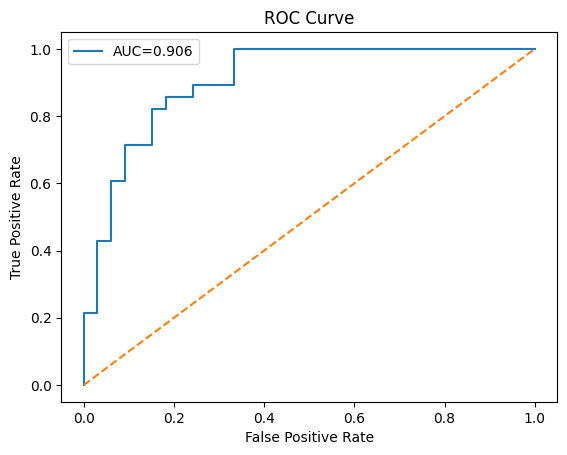

In [7]:
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig(REPORTS_DIR / f"roc_curve_{best_run}.png", bbox_inches="tight")
plt.show()


## Precision-Recall curve

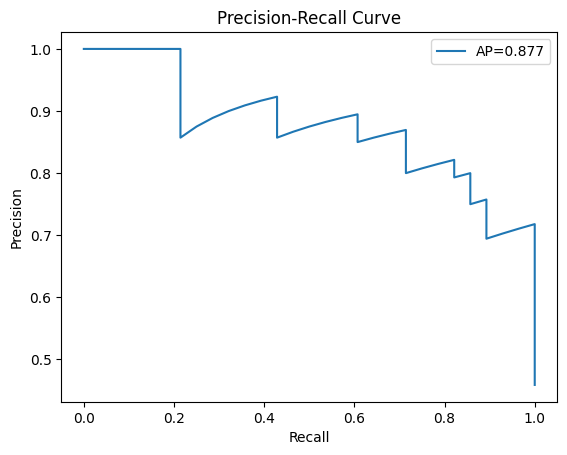

In [8]:
precision, recall, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

plt.figure()
plt.plot(recall, precision, label=f"AP={ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig(REPORTS_DIR / f"pr_curve_{best_run}.png", bbox_inches="tight")
plt.show()


## 7) Confusion matrix (@0.5) _ classification report

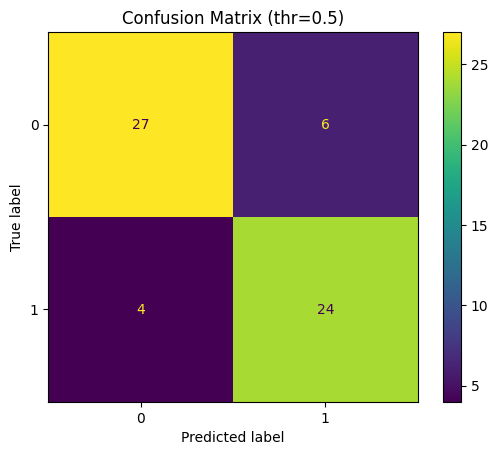

              precision    recall  f1-score   support

           0      0.871     0.818     0.844        33
           1      0.800     0.857     0.828        28

    accuracy                          0.836        61
   macro avg      0.835     0.838     0.836        61
weighted avg      0.838     0.836     0.836        61



In [9]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix (thr=0.5)")
plt.savefig(REPORTS_DIR / f"confusion_matrix_{best_run}.png", bbox_inches="tight")
plt.show()

print(classification_report(y_test, preds, digits=3))


## Calibration plot

<Figure size 640x480 with 0 Axes>

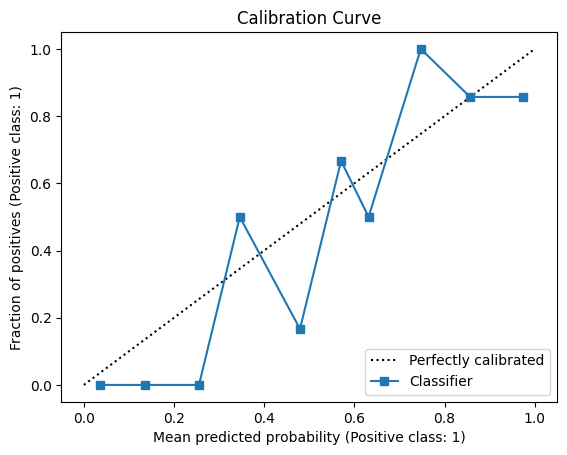

In [10]:
plt.figure()
CalibrationDisplay.from_predictions(y_test, proba, n_bins=10)
plt.title("Calibration Curve")
plt.savefig(REPORTS_DIR / f"calibration_curve_{best_run}.png", bbox_inches="tight")
plt.show()


## Threshold sweep

In [11]:
def sweep_thresholds(y_true, p, steps=101):
    thrs = np.linspace(0, 1, steps)
    rows = []
    for t in thrs:
        pred = (p >= t).astype(int)
        rows.append({
            "thr": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0)
        })
    return pd.DataFrame(rows)

thr_df = sweep_thresholds(y_test, proba)
thr_df.head()


,thr,precision,recall,f1
0,0.00,0.459016,1.0,0.629213
1,0.01,0.459016,1.0,0.629213
2,0.02,0.482759,1.0,0.651163
3,0.03,0.500000,1.0,0.666667
4,0.04,0.528302,1.0,0.691358


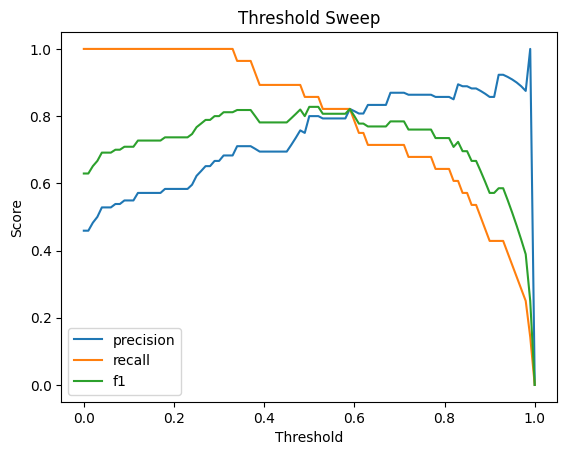

(0.5,
 thr          0.500000
 precision    0.800000
 recall       0.857143
 f1           0.827586
 Name: 50, dtype: float64)

In [12]:
# visualize precision/recall/f1 vs threshold
plt.figure()
plt.plot(thr_df["thr"], thr_df["precision"], label="precision")
plt.plot(thr_df["thr"], thr_df["recall"],    label="recall")
plt.plot(thr_df["thr"], thr_df["f1"],        label="f1")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Threshold Sweep")
plt.legend()
plt.savefig(REPORTS_DIR / f"threshold_sweep_{best_run}.png", bbox_inches="tight")
plt.show()

# best-F1 threshold (or choose per business need)
best_idx = thr_df["f1"].idxmax()
best_thr = float(thr_df.loc[best_idx, "thr"])
best_thr, thr_df.loc[best_idx]


## 11) Feature importance / coefficients

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Try to extract final estimator
final_est = getattr(pipe, "named_steps", {}).get("model", None)
if final_est is None:
    # pipeline may be Pipeline([("pre", ...), ("model", ...)])
    try:
        final_est = pipe.named_steps["model"]
    except Exception:
        final_est = None

try:
    if isinstance(final_est, LogisticRegression):
        coefs = final_est.coef_[0]
        # try to recover names if available
        # (if you have get_feature_names helper, use it here)
        print("Top positive coefficients:")
        top_pos = np.argsort(coefs)[-10:][::-1]
        print(list(zip(top_pos, coefs[top_pos])))
        print("Top negative coefficients:")
        top_neg = np.argsort(coefs)[:10]
        print(list(zip(top_neg, coefs[top_neg])))

    elif isinstance(final_est, RandomForestClassifier):
        importances = final_est.feature_importances_
        top_idx = np.argsort(importances)[-15:][::-1]
        plt.figure(figsize=(6,5))
        plt.bar(range(len(top_idx)), importances[top_idx])
        plt.xticks(range(len(top_idx)), top_idx, rotation=90)
        plt.title("Random Forest Feature Importances (index-based)")
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / f"feature_importances_{best_run}.png", bbox_inches="tight")
        plt.show()
    else:
        print("Feature importance visualization not implemented for this estimator.")
except Exception as e:
    print("Could not compute importances:", e)


Top positive coefficients:
[(np.int64(30), np.float64(1.0397570776522163)), (np.int64(4), np.float64(0.8965461241456266)), (np.int64(26), np.float64(0.8638730764445405)), (np.int64(34), np.float64(0.7218255315612542)), (np.int64(21), np.float64(0.6534197257665578)), (np.int64(9), np.float64(0.4451790443426571)), (np.int64(32), np.float64(0.3832711573708165)), (np.int64(1), np.float64(0.36086087578323284)), (np.int64(22), np.float64(0.35085607331703933)), (np.int64(13), np.float64(0.30383180379914637))]
Top negative coefficients:
[(np.int64(20), np.float64(-1.2566560978643166)), (np.int64(29), np.float64(-0.8112627940915604)), (np.int64(33), np.float64(-0.6676581289913166)), (np.int64(24), np.float64(-0.6116761425811491)), (np.int64(8), np.float64(-0.44065481778357096)), (np.int64(14), np.float64(-0.3727370236135535)), (np.int64(27), np.float64(-0.34166170494349424)), (np.int64(17), np.float64(-0.3324482539880619)), (np.int64(12), np.float64(-0.2993075772400591)), (np.int64(3), np.float

## 12) SHAP summary (if tree model & SHAP installed)

In [14]:
try:
    import shap
    shap_explainer = None

    # Choose explainer based on estimator type
    from sklearn.ensemble import RandomForestClassifier
    if isinstance(final_est, RandomForestClassifier):
        shap_explainer = shap.TreeExplainer(final_est)
        X_trans = pipe.named_steps["pre"].transform(X_test) if "pre" in pipe.named_steps else X_test
        shap_values = shap_explainer.shap_values(X_trans)
        shap.summary_plot(shap_values[1], X_trans, show=True)
    else:
        print("SHAP demo: implemented here for tree-based model example.")
except Exception as e:
    print("SHAP not available or failed:", e)


SHAP demo: implemented here for tree-based model example.


## 13) Save an evaluation report bundle

In [15]:
bundle = {
    "run_id": best_run,
    "metrics": metrics,
    "best_threshold_by_f1": best_thr
}
(REPORTS_DIR / f"evaluation_summary_{best_run}.json").write_text(json.dumps(bundle, indent=2))
print("Wrote:", REPORTS_DIR / f"evaluation_summary_{best_run}.json")


Wrote: reports/evaluation_summary_logreg_seed42_1761362412.json
